# A lógica do teste de hipótese

**Tema:** Estatística › Testes de Hipótese

Este notebook constrói um teste de hipótese **do zero**, por simulação, antes
de usar qualquer função pronta. O objetivo é que `stats.ttest_ind` deixe de ser
uma caixa-preta.

> **A pergunta que um teste responde, em uma frase:** *se não houvesse efeito
> nenhum, com que frequência eu veria algo tão extremo quanto o que vi?*
>
> **Analogia:** o teste é um júri. $H_0$ é a presunção de inocência. Você não
> prova inocência — decide apenas se há evidência **além da dúvida razoável**
> para condenar. O nível $\alpha$ é a sua definição operacional de "dúvida
> razoável".

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(808)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
AZUL, VERDE, VERMELHO, ROXO, AMBAR = "#1F5C8B", "#1E6B4F", "#9C2B2B", "#5B3E86", "#8A6100"
print("pronto")

pronto


## 1. Construindo a distribuição nula à mão

**Cenário:** um novo layout de checkout. Grupo A (controle) e grupo B
(tratamento), 800 usuários cada. Observamos uma diferença de conversão.

A pergunta: essa diferença é grande o suficiente para ser incompatível com "os
dois layouts são idênticos"?

Em vez de aplicar uma fórmula, vamos **simular o mundo em que $H_0$ é
verdadeira** e ver como a diferença se distribui lá.

In [2]:
n_a = n_b = 800
p_verdadeiro_a = 0.120
p_verdadeiro_b = 0.148       # o efeito REAL existe (mas o teste não sabe disso)

grupo_a = rng.random(n_a) < p_verdadeiro_a
grupo_b = rng.random(n_b) < p_verdadeiro_b

p_hat_a, p_hat_b = grupo_a.mean(), grupo_b.mean()
diferenca_observada = p_hat_b - p_hat_a

print(f"Grupo A: {grupo_a.sum():>4d} conversões em {n_a} -> {p_hat_a:.4f}")
print(f"Grupo B: {grupo_b.sum():>4d} conversões em {n_b} -> {p_hat_b:.4f}")
print(f"\nDiferença observada: {diferenca_observada:+.4f} "
      f"({diferenca_observada/p_hat_a:+.1%} relativo)")

Grupo A:   98 conversões em 800 -> 0.1225
Grupo B:  111 conversões em 800 -> 0.1388

Diferença observada: +0.0163 (+13.3% relativo)


### O teste de permutação: a lógica do teste, sem nenhuma fórmula

Se $H_0$ for verdadeira — se o layout não faz diferença nenhuma — então o
rótulo "A" ou "B" de cada usuário é **irrelevante**. Poderíamos embaralhar os
rótulos e nada mudaria em essência.

Então é isso que fazemos: embaralhamos os rótulos 20.000 vezes e vemos que
diferenças aparecem **só por acaso**.

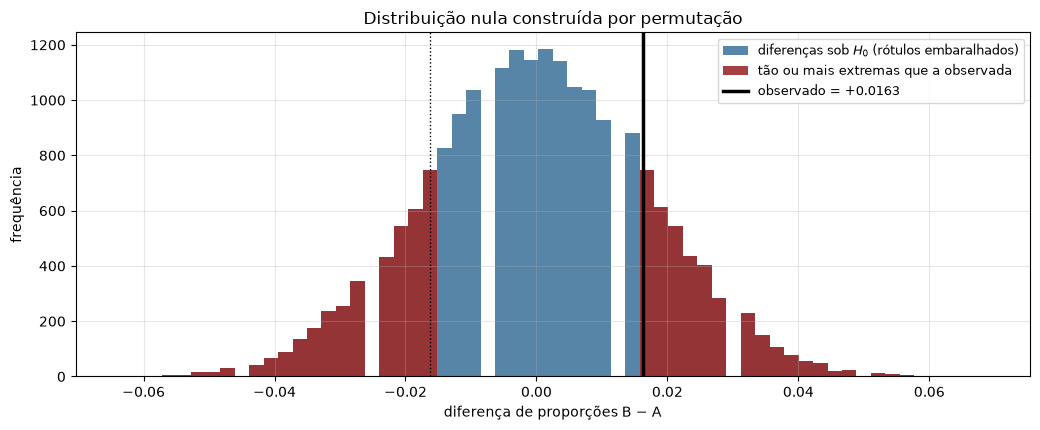

p-valor por permutação : 0.3765
p-valor pelo teste z   : 0.3348

Os dois praticamente coincidem — mas o de permutação não
usou NENHUMA fórmula nem NENHUMA suposição de distribuição.


In [3]:
combinado = np.concatenate([grupo_a, grupo_b])
N_PERMUTACOES = 20_000

# Embaralha os rótulos e recalcula a diferença, N vezes
diferencas_nulas = np.empty(N_PERMUTACOES)
for i in range(N_PERMUTACOES):
    embaralhado = rng.permutation(combinado)
    diferencas_nulas[i] = embaralhado[n_a:].mean() - embaralhado[:n_a].mean()

# p-valor bilateral: fração de diferenças nulas tão ou mais extremas
p_permutacao = np.mean(np.abs(diferencas_nulas) >= np.abs(diferenca_observada))

fig, ax = plt.subplots(figsize=(10.5, 4.4))
ax.hist(diferencas_nulas, bins=60, color=AZUL, alpha=0.75, edgecolor="none",
        label="diferenças sob $H_0$ (rótulos embaralhados)")
extremos = np.abs(diferencas_nulas) >= np.abs(diferenca_observada)
ax.hist(diferencas_nulas[extremos], bins=60, color=VERMELHO, alpha=0.9,
        edgecolor="none", label="tão ou mais extremas que a observada")
ax.axvline(diferenca_observada, color="black", lw=2.5,
           label=f"observado = {diferenca_observada:+.4f}")
ax.axvline(-diferenca_observada, color="black", lw=1, ls=":")
ax.set_xlabel("diferença de proporções B − A")
ax.set_ylabel("frequência")
ax.set_title("Distribuição nula construída por permutação")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f"p-valor por permutação : {p_permutacao:.4f}")
print(f"p-valor pelo teste z   : "
      f"{stats.norm.sf(abs(diferenca_observada) / np.sqrt(combinado.mean()*(1-combinado.mean())*(1/n_a+1/n_b)))*2:.4f}")
print("\nOs dois praticamente coincidem — mas o de permutação não")
print("usou NENHUMA fórmula nem NENHUMA suposição de distribuição.")

> **O teste de permutação é a definição operacional do p-valor.** Toda fórmula
> de teste clássico é um atalho analítico para o que acabamos de fazer por
> força bruta. Quando os pressupostos da fórmula não valem, a permutação
> continua valendo.

## 2. O que $\alpha$ realmente controla

Vamos simular **10.000 experimentos em que $H_0$ é literalmente verdadeira**
(nenhum efeito) e contar quantas vezes rejeitamos.

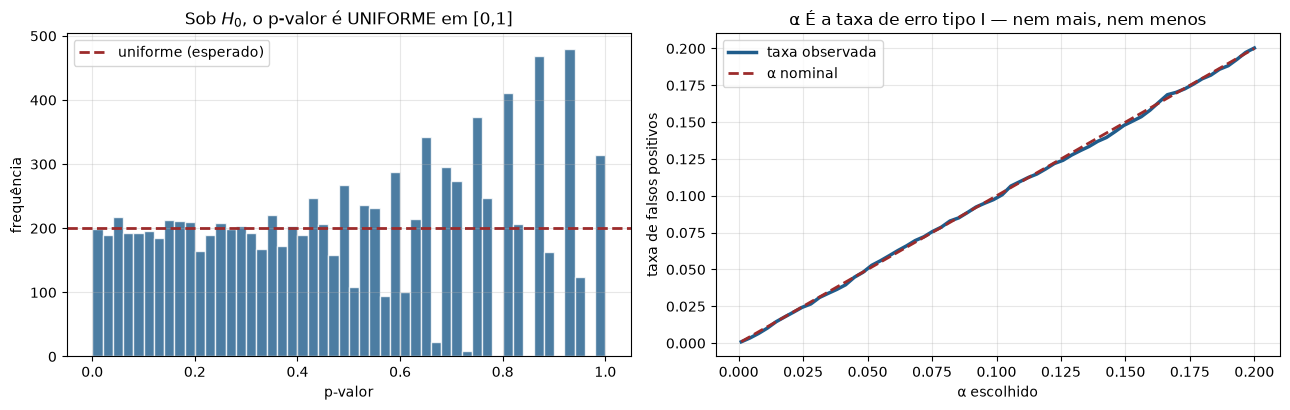

α = 0.01  ->  rejeitamos em 0.0095 dos 10,000 experimentos SEM efeito
α = 0.05  ->  rejeitamos em 0.0510 dos 10,000 experimentos SEM efeito
α = 0.10  ->  rejeitamos em 0.0990 dos 10,000 experimentos SEM efeito


In [4]:
N_EXP = 10_000
p_comum = 0.12
n = 800

a = rng.binomial(n, p_comum, N_EXP) / n
b = rng.binomial(n, p_comum, N_EXP) / n
p_pool = (a + b) / 2
ep = np.sqrt(p_pool * (1 - p_pool) * (2 / n))
z = (b - a) / ep
p_valores = 2 * stats.norm.sf(np.abs(z))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.2))
ax1.hist(p_valores, bins=50, color=AZUL, alpha=0.8, edgecolor="white")
ax1.axhline(N_EXP / 50, ls="--", color=VERMELHO, lw=2, label="uniforme (esperado)")
ax1.set_xlabel("p-valor")
ax1.set_ylabel("frequência")
ax1.set_title("Sob $H_0$, o p-valor é UNIFORME em [0,1]")
ax1.legend()

alphas = np.linspace(0.001, 0.20, 60)
taxas = [(p_valores < al).mean() for al in alphas]
ax2.plot(alphas, taxas, lw=2.5, color=AZUL, label="taxa observada")
ax2.plot(alphas, alphas, "--", lw=2, color=VERMELHO, label="α nominal")
ax2.set_xlabel("α escolhido")
ax2.set_ylabel("taxa de falsos positivos")
ax2.set_title("α É a taxa de erro tipo I — nem mais, nem menos")
ax2.legend()
plt.tight_layout()
plt.show()

for al in [0.01, 0.05, 0.10]:
    print(f"α = {al:.2f}  ->  rejeitamos em {(p_valores < al).mean():.4f} "
          f"dos {N_EXP:,} experimentos SEM efeito")

O painel da esquerda é um resultado que surpreende quem vê pela primeira vez:
**sob $H_0$, o p-valor é uniformemente distribuído**. Um p-valor de 0,03 é
exatamente tão provável quanto um de 0,73 quando não há efeito nenhum.

Isso tem uma consequência prática direta: **p-valores próximos de 0,05 são
fracos**. Eles ocorrem com frequência confortável mesmo sem efeito.

## 3. Erros tipo I e tipo II, lado a lado

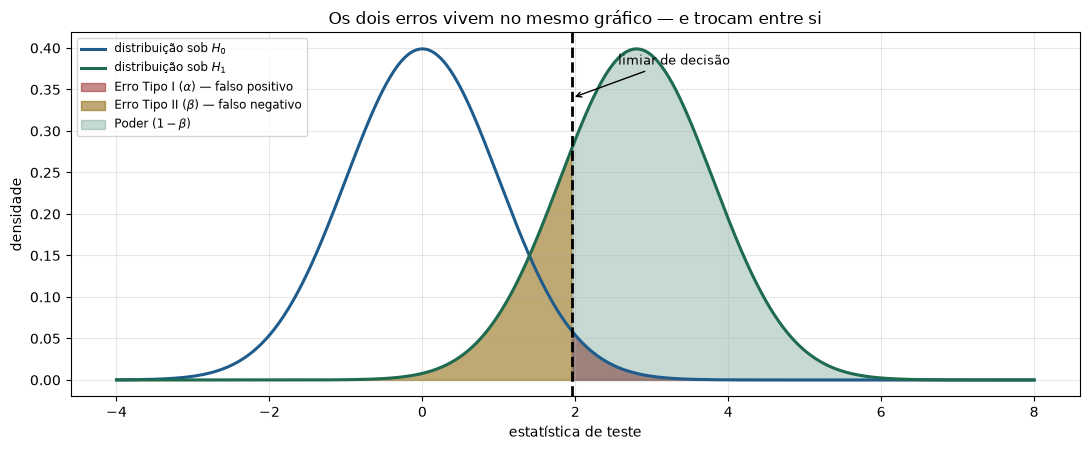

Com efeito de 2.8 erros-padrão e α = 0,05:
   α (erro tipo I)  = 0,050
   β (erro tipo II) = 0.200
   poder            = 0.800

Mova o limiar para a direita: α cai, β sobe. E vice-versa.
Só aumentar n (ou reduzir a variância) melhora os dois ao mesmo tempo.


In [5]:
# Duas distribuições da estatística de teste: sob H0 e sob H1
efeito_real = 2.8       # em unidades de erro-padrão
grade = np.linspace(-4, 8, 800)
dist_h0 = stats.norm.pdf(grade, 0, 1)
dist_h1 = stats.norm.pdf(grade, efeito_real, 1)
z_critico = stats.norm.ppf(0.975)

fig, ax = plt.subplots(figsize=(11, 4.6))
ax.plot(grade, dist_h0, lw=2.2, color=AZUL, label="distribuição sob $H_0$")
ax.plot(grade, dist_h1, lw=2.2, color=VERDE, label="distribuição sob $H_1$")
ax.fill_between(grade, dist_h0, where=(grade > z_critico), color=VERMELHO,
                alpha=0.55, label=r"Erro Tipo I ($\alpha$) — falso positivo")
ax.fill_between(grade, dist_h1, where=(grade < z_critico), color=AMBAR,
                alpha=0.55, label=r"Erro Tipo II ($\beta$) — falso negativo")
ax.fill_between(grade, dist_h1, where=(grade > z_critico), color=VERDE,
                alpha=0.25, label=r"Poder ($1-\beta$)")
ax.axvline(z_critico, color="black", lw=2, ls="--")
ax.annotate("limiar de decisão", xy=(z_critico, 0.34),
            xytext=(z_critico + 0.6, 0.38), fontsize=9,
            arrowprops=dict(arrowstyle="->", lw=1))
ax.set_xlabel("estatística de teste")
ax.set_ylabel("densidade")
ax.set_title("Os dois erros vivem no mesmo gráfico — e trocam entre si")
ax.legend(fontsize=8.5, loc="upper left")
plt.tight_layout()
plt.show()

poder = stats.norm.sf(z_critico - efeito_real)
print(f"Com efeito de {efeito_real} erros-padrão e α = 0,05:")
print(f"   α (erro tipo I)  = 0,050")
print(f"   β (erro tipo II) = {1-poder:.3f}")
print(f"   poder            = {poder:.3f}")
print("\nMova o limiar para a direita: α cai, β sobe. E vice-versa.")
print("Só aumentar n (ou reduzir a variância) melhora os dois ao mesmo tempo.")

## 4. Significância estatística ≠ relevância prática

Este é o erro mais caro do mercado. Vamos torná-lo impossível de esquecer.

In [6]:
efeito_minusculo = 0.0004      # 0,04 p.p. de diferença absoluta — irrelevante
p_base = 0.120

linhas = []
for n in [1_000, 10_000, 100_000, 1_000_000, 10_000_000]:
    # valor esperado do z com esse efeito e esse n
    ep = np.sqrt(2 * p_base * (1 - p_base) / n)
    z_esperado = efeito_minusculo / ep
    p_esperado = 2 * stats.norm.sf(abs(z_esperado))
    # intervalo de confiança do efeito
    margem = 1.96 * ep
    linhas.append({
        "n por grupo": n,
        "efeito (p.p.)": efeito_minusculo * 100,
        "p-valor esperado": p_esperado,
        "significativo?": "SIM" if p_esperado < 0.05 else "não",
        "IC 95% do efeito (p.p.)": f"[{(efeito_minusculo-margem)*100:+.3f}, "
                                   f"{(efeito_minusculo+margem)*100:+.3f}]",
    })
print("O MESMO efeito de 0,04 pontos percentuais, em amostras crescentes:\n")
print(pd.DataFrame(linhas).to_string(index=False,
      formatters={"n por grupo": "{:,}".format,
                  "p-valor esperado": "{:.2e}".format}))

print("\nCom n suficiente, QUALQUER diferença não-nula fica significativa.")
print("A pergunta certa nunca é 'é significativo?', e sim:")
print("   'o intervalo de confiança do efeito exclui o mínimo relevante?'")

O MESMO efeito de 0,04 pontos percentuais, em amostras crescentes:



n por grupo  efeito (p.p.) p-valor esperado significativo? IC 95% do efeito (p.p.)
      1,000           0.04         9.78e-01            não        [-2.808, +2.888]
     10,000           0.04         9.31e-01            não        [-0.861, +0.941]
    100,000           0.04         7.83e-01            não        [-0.245, +0.325]
  1,000,000           0.04         3.84e-01            não        [-0.050, +0.130]
 10,000,000           0.04         5.92e-03            SIM        [+0.012, +0.068]

Com n suficiente, QUALQUER diferença não-nula fica significativa.
A pergunta certa nunca é 'é significativo?', e sim:
   'o intervalo de confiança do efeito exclui o mínimo relevante?'


> **Prática que resolve o problema:** antes do experimento, defina o **efeito
> mínimo relevante** (MDE — *minimum detectable effect*) com o time de negócio.
> Depois, em vez de perguntar "$p < 0{,}05$?", pergunte "o IC do efeito está
> inteiramente acima do MDE?". Isso é um **teste de equivalência /
> não-inferioridade**, e é o que times maduros de experimentação usam.

## 5. Espiar os dados: como inflar o erro tipo I sem perceber

Um analista roda o teste todo dia e para quando fica significativo. Parece
eficiente. Vamos medir o estrago.

Experimentos SEM efeito nenhum. Taxa de falso positivo:

  nº de espiadas    parando na 1ª significância    só no final
----------------------------------------------------------------
               1                          4.8%          4.8%
               2                          8.0%          4.5%
               5                         13.8%          4.6%
              10                         19.8%          5.2%
              20                         24.9%          5.1%
              50                         32.0%          4.6%


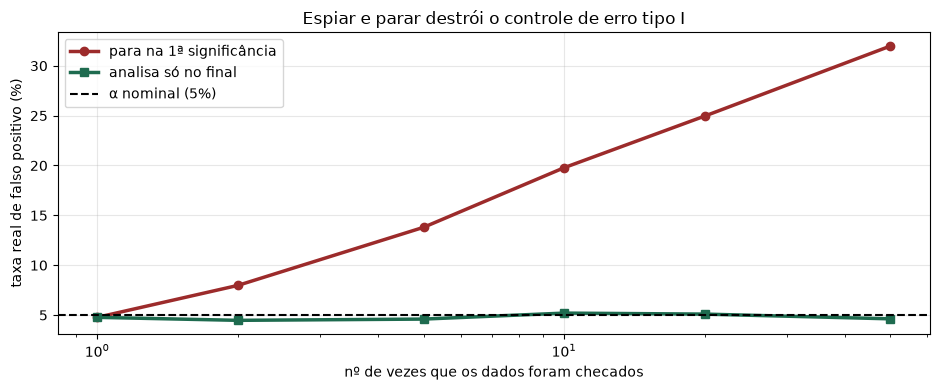

In [7]:
def simula_com_espiadas(n_final, n_espiadas, n_exp=4_000, p=0.12):
    """Simula experimentos SEM efeito, checando significância várias vezes."""
    pontos = np.linspace(n_final / n_espiadas, n_final, n_espiadas).astype(int)
    rejeitou_alguma_vez = np.zeros(n_exp, dtype=bool)
    rejeitou_so_no_fim = np.zeros(n_exp, dtype=bool)

    a_acum = np.zeros(n_exp)
    b_acum = np.zeros(n_exp)
    anterior = 0
    for k, ponto in enumerate(pontos):
        novos = ponto - anterior
        a_acum += rng.binomial(novos, p, n_exp)
        b_acum += rng.binomial(novos, p, n_exp)
        anterior = ponto

        pa, pb = a_acum / ponto, b_acum / ponto
        pool = (pa + pb) / 2
        ep = np.sqrt(np.maximum(pool * (1 - pool), 1e-12) * (2 / ponto))
        pval = 2 * stats.norm.sf(np.abs((pb - pa) / ep))
        rejeitou_alguma_vez |= pval < 0.05
        if k == len(pontos) - 1:
            rejeitou_so_no_fim = pval < 0.05
    return rejeitou_alguma_vez.mean(), rejeitou_so_no_fim.mean()


print("Experimentos SEM efeito nenhum. Taxa de falso positivo:\n")
print(f"{'nº de espiadas':>16s} {'parando na 1ª significância':>30s} {'só no final':>14s}")
print("-" * 64)
resultados_espiada = []
for k in [1, 2, 5, 10, 20, 50]:
    taxa_espiando, taxa_fim = simula_com_espiadas(20_000, k)
    resultados_espiada.append({"espiadas": k, "espiando": taxa_espiando,
                               "só no fim": taxa_fim})
    print(f"{k:>16d} {taxa_espiando:>29.1%} {taxa_fim:>13.1%}")

fig, ax = plt.subplots(figsize=(9.5, 4))
re = pd.DataFrame(resultados_espiada)
ax.plot(re["espiadas"], re["espiando"] * 100, "o-", lw=2.5, color=VERMELHO,
        label="para na 1ª significância")
ax.plot(re["espiadas"], re["só no fim"] * 100, "s-", lw=2.5, color=VERDE,
        label="analisa só no final")
ax.axhline(5, ls="--", color="black", lw=1.5, label="α nominal (5%)")
ax.set_xscale("log")
ax.set_xlabel("nº de vezes que os dados foram checados")
ax.set_ylabel("taxa real de falso positivo (%)")
ax.set_title("Espiar e parar destrói o controle de erro tipo I")
ax.legend()
plt.tight_layout()
plt.show()

Com 20 espiadas, a taxa real de falso positivo passa de 5% para bem acima de
20%. O analista acredita estar operando a 5%.

> **As soluções corretas** (tema do módulo de A/B testing):
> - **Fixar o $n$ antes** e olhar só no final (o mais simples).
> - **Fronteiras sequenciais** de O'Brien-Fleming ou Pocock, que ajustam o
>   limiar a cada espiada.
> - **Testes sempre válidos** (razão de verossimilhança / *e-values*), que
>   permitem monitorar continuamente sem inflar $\alpha$.

## 6. Um teste de hipótese ponta a ponta, do jeito certo

In [8]:
def relatorio_ab(conv_a, n_a, conv_b, n_b, mde_relativo=0.05, alpha=0.05):
    """Relatório completo: efeito, IC, p-valor E decisão de negócio."""
    pa, pb = conv_a / n_a, conv_b / n_b
    efeito_abs = pb - pa
    efeito_rel = efeito_abs / pa

    # IC da diferença (não agrupado — para estimar o efeito, não testar H0)
    ep_dif = np.sqrt(pa * (1 - pa) / n_a + pb * (1 - pb) / n_b)
    z = stats.norm.ppf(1 - alpha / 2)
    ic = (efeito_abs - z * ep_dif, efeito_abs + z * ep_dif)

    # Teste (agrupado — sob H0 as proporções são iguais)
    pool = (conv_a + conv_b) / (n_a + n_b)
    ep_h0 = np.sqrt(pool * (1 - pool) * (1 / n_a + 1 / n_b))
    z_obs = efeito_abs / ep_h0
    pval = 2 * stats.norm.sf(abs(z_obs))

    mde_abs = pa * mde_relativo
    print(f"Controle   : {conv_a:>6,} / {n_a:>7,} = {pa:.4f}")
    print(f"Tratamento : {conv_b:>6,} / {n_b:>7,} = {pb:.4f}")
    print(f"\nEfeito absoluto : {efeito_abs*100:+.3f} p.p.")
    print(f"Efeito relativo : {efeito_rel:+.2%}")
    print(f"IC 95% do efeito: [{ic[0]*100:+.3f}, {ic[1]*100:+.3f}] p.p.")
    print(f"p-valor         : {pval:.4f}")
    print(f"\nMDE definido antes ({mde_relativo:.0%} relativo) = "
          f"{mde_abs*100:.3f} p.p.")
    print("-" * 62)
    if pval >= alpha:
        print("DECISÃO: não há evidência suficiente de efeito.")
        if ic[1] < mde_abs:
            print("         E o IC exclui o MDE -> podemos afirmar que o efeito,")
            print("         se existe, é MENOR que o mínimo relevante. Descartar.")
        else:
            print("         Mas o IC ainda inclui o MDE -> INCONCLUSIVO.")
            print("         Precisamos de mais amostra, não de uma decisão.")
    elif ic[0] > mde_abs:
        print("DECISÃO: efeito significativo E todo o IC acima do mínimo relevante.")
        print("         Recomendar implantação.")
    elif ic[1] < mde_abs:
        print("DECISÃO: significativo, porém o IC INTEIRO está abaixo do MDE.")
        print("         O efeito é real e comprovadamente irrelevante.")
        print("         Não implantar: o ganho não paga o custo de manutenção.")
    else:
        print("DECISÃO: significativo, mas o IC cruza o MDE.")
        print("         Pode ou não valer a pena. Levar o IC ao negócio,")
        print("         ou coletar mais amostra para estreitá-lo.")


print("=" * 62)
print("CASO 1 — efeito real e relevante")
print("=" * 62)
relatorio_ab(conv_a=1_180, n_a=10_000, conv_b=1_390, n_b=10_000)

print("\n" + "=" * 62)
print("CASO 2 — significativo, mas trivialmente pequeno (n gigante)")
print("=" * 62)
relatorio_ab(conv_a=120_100, n_a=1_000_000, conv_b=121_600, n_b=1_000_000)

print("\n" + "=" * 62)
print("CASO 3 — inconclusivo (amostra insuficiente)")
print("=" * 62)
relatorio_ab(conv_a=118, n_a=1_000, conv_b=131, n_b=1_000)

CASO 1 — efeito real e relevante
Controle   :  1,180 /  10,000 = 0.1180
Tratamento :  1,390 /  10,000 = 0.1390

Efeito absoluto : +2.100 p.p.
Efeito relativo : +17.80%
IC 95% do efeito: [+1.173, +3.027] p.p.
p-valor         : 0.0000

MDE definido antes (5% relativo) = 0.590 p.p.
--------------------------------------------------------------
DECISÃO: efeito significativo E todo o IC acima do mínimo relevante.
         Recomendar implantação.

CASO 2 — significativo, mas trivialmente pequeno (n gigante)
Controle   : 120,100 / 1,000,000 = 0.1201
Tratamento : 121,600 / 1,000,000 = 0.1216

Efeito absoluto : +0.150 p.p.
Efeito relativo : +1.25%
IC 95% do efeito: [+0.060, +0.240] p.p.
p-valor         : 0.0011

MDE definido antes (5% relativo) = 0.601 p.p.
--------------------------------------------------------------
DECISÃO: significativo, porém o IC INTEIRO está abaixo do MDE.
         O efeito é real e comprovadamente irrelevante.
         Não implantar: o ganho não paga o custo de manuten

Os três casos cobrem as situações que você vai encontrar na prática. Note que
**"não significativo" se divide em dois desfechos muito diferentes**:
"descartado com segurança" e "inconclusivo". Um relatório que não distingue os
dois é um relatório incompleto.

## 7. Exercícios

1. Refaça a seção 1 com um teste de permutação para a **diferença de medianas**
   de duas amostras log-normais. Compare com o teste t. Qual é válido?
2. Na seção 2, troque a binomial por uma distribuição fortemente assimétrica e
   use o teste t. O p-valor ainda é uniforme sob $H_0$? A partir de que $n$?
3. Implemente a fronteira de **Pocock** (limiar constante ajustado) para 5
   espiadas e verifique que ela restaura a taxa de erro em 5%.
4. Escreva a versão do `relatorio_ab` para **médias** (receita por usuário) em
   vez de proporções, usando o teste de Welch.

## Próximo passo

`02-testes-classicos.ipynb` — o catálogo de testes, com seus pressupostos
testados empiricamente.